In [18]:
import pandas as pd
import matplotlib.pyplot as plt


In [19]:
df = pd.read_csv('../ncbi_590_data.csv')
df = df[df['is_usa_based'] == 1]
df['collection_year'] = pd.to_numeric(df['collection_year'], errors='coerce')
df = df[df['collection_year'] >= 2005]
df = df[df['month'].notna()]
#convert collection_year to str
df['collection_year'] = df['collection_year'].astype(str)
df['collection_year'] = df['collection_year'].str[:4]

C:\Users\bryan\AppData\Local\Temp\ipykernel_31432\205312839.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../ncbi_590_data.csv')


In [20]:
df.head(10)

,genome,geo_loc_name,collection_date,strain,host,serotype,isolate,isolation_source,source_type,geo_loc_name_is_missing,is_usa_based,usa_state,new_isolation_source,collection_year,month,nors_primary_mode_map
6,GCA_000188955.5,USA,2010-02-01,507440-20,NaN,NaN,NaN,environmental swab,environmental,False,1.0,Unknown,Environment,2010,2.0,Environmental contamination other than food/water
8,GCA_000231465.2,"USA: Queens, New York",2005-12,FSL A4-669,Homo sapiens,NaN,NaN,unspecified,NaN,False,1.0,NEW YORK,Uncategorized,2005,12.0,unspecified
9,GCA_000231485.2,"USA: Westchester, New York",2006-11,FSL R6-377,Homo sapiens,NaN,NaN,unspecified,NaN,False,1.0,NEW YORK,Uncategorized,2006,11.0,unspecified
10,GCA_000231505.2,"USA: Suffolk, New York",2005-05,FSL A4-567,Homo sapiens,NaN,NaN,unspecified,NaN,False,1.0,NEW YORK,Uncategorized,2005,5.0,unspecified
12,GCA_000231545.2,"USA: Richmond, New York",2005-08,FSL A4-620,Homo sapiens,NaN,NaN,unspecified,NaN,False,1.0,RHODE ISLAND,Uncategorized,2005,8.0,unspecified
13,GCA_000231565.2,USA: New York,2005-10,FSL R8-3668,Homo sapiens,NaN,NaN,unspecified,NaN,False,1.0,NEW YORK,Uncategorized,2005,10.0,unspecified
14,GCA_000231585.2,"USA: Orange county, New York",2005-03,FSL S5-703,Homo sapiens,NaN,NaN,unspecified,NaN,False,1.0,OREGON,Uncategorized,2005,3.0,unspecified
15,GCA_000231605.2,"USA: Erie, New York",2005-09,FSL A4-603,Homo sapiens,NaN,NaN,unspecified,NaN,False,1.0,NEW YORK,Uncategorized,2005,9.0,unspecified
16,GCA_000231625.2,"USA: Erie, New York",2005-10,A4-633,Homo sapiens,NaN,FSL A4-633,Unspecified,NaN,False,1.0,NEW YORK,Uncategorized,2005,10.0,Unspecified
17,GCA_000231665.2,"USA: Albany County, New York",2005-11,FSL A4-653,Homo sapiens,NaN,NaN,unspecified,NaN,False,1.0,NEW YORK,Uncategorized,2005,11.0,unspecified


In [21]:
df['collection_year'].value_counts()

collection_year
2019    41162
2020    38513
2022    37636
2021    36402
2018    30166
2017    23032
2016    12075
2015     8212
2014     5301
2023     3617
2010     2562
2013     2366
2011     2137
2012     2088
2007     1693
2009      995
2008      936
2006      705
2005      616
Name: count, dtype: int64

In [22]:

#recode months to be 01, 02, ..., 12
df['month'] = df['month'].astype(int)
df['month'] = df['month'].apply(lambda x: f"{x:02d}")
df['month'].value_counts()

month
08    31365
07    30478
09    29900
10    25765
06    23691
05    19543
11    18728
04    16180
01    14870
12    14487
03    13448
02    11759
Name: count, dtype: int64

In [23]:
df['year_and_month'] = df['collection_year'] + '-' + df['month']
df.head(10)



,genome,geo_loc_name,collection_date,strain,host,serotype,isolate,isolation_source,source_type,geo_loc_name_is_missing,is_usa_based,usa_state,new_isolation_source,collection_year,month,nors_primary_mode_map,year_and_month
6,GCA_000188955.5,USA,2010-02-01,507440-20,NaN,NaN,NaN,environmental swab,environmental,False,1.0,Unknown,Environment,2010,02,Environmental contamination other than food/water,2010-02
8,GCA_000231465.2,"USA: Queens, New York",2005-12,FSL A4-669,Homo sapiens,NaN,NaN,unspecified,NaN,False,1.0,NEW YORK,Uncategorized,2005,12,unspecified,2005-12
9,GCA_000231485.2,"USA: Westchester, New York",2006-11,FSL R6-377,Homo sapiens,NaN,NaN,unspecified,NaN,False,1.0,NEW YORK,Uncategorized,2006,11,unspecified,2006-11
10,GCA_000231505.2,"USA: Suffolk, New York",2005-05,FSL A4-567,Homo sapiens,NaN,NaN,unspecified,NaN,False,1.0,NEW YORK,Uncategorized,2005,05,unspecified,2005-05
12,GCA_000231545.2,"USA: Richmond, New York",2005-08,FSL A4-620,Homo sapiens,NaN,NaN,unspecified,NaN,False,1.0,RHODE ISLAND,Uncategorized,2005,08,unspecified,2005-08
13,GCA_000231565.2,USA: New York,2005-10,FSL R8-3668,Homo sapiens,NaN,NaN,unspecified,NaN,False,1.0,NEW YORK,Uncategorized,2005,10,unspecified,2005-10
14,GCA_000231585.2,"USA: Orange county, New York",2005-03,FSL S5-703,Homo sapiens,NaN,NaN,unspecified,NaN,False,1.0,OREGON,Uncategorized,2005,03,unspecified,2005-03
15,GCA_000231605.2,"USA: Erie, New York",2005-09,FSL A4-603,Homo sapiens,NaN,NaN,unspecified,NaN,False,1.0,NEW YORK,Uncategorized,2005,09,unspecified,2005-09
16,GCA_000231625.2,"USA: Erie, New York",2005-10,A4-633,Homo sapiens,NaN,FSL A4-633,Unspecified,NaN,False,1.0,NEW YORK,Uncategorized,2005,10,Unspecified,2005-10
17,GCA_000231665.2,"USA: Albany County, New York",2005-11,FSL A4-653,Homo sapiens,NaN,NaN,unspecified,NaN,False,1.0,NEW YORK,Uncategorized,2005,11,unspecified,2005-11


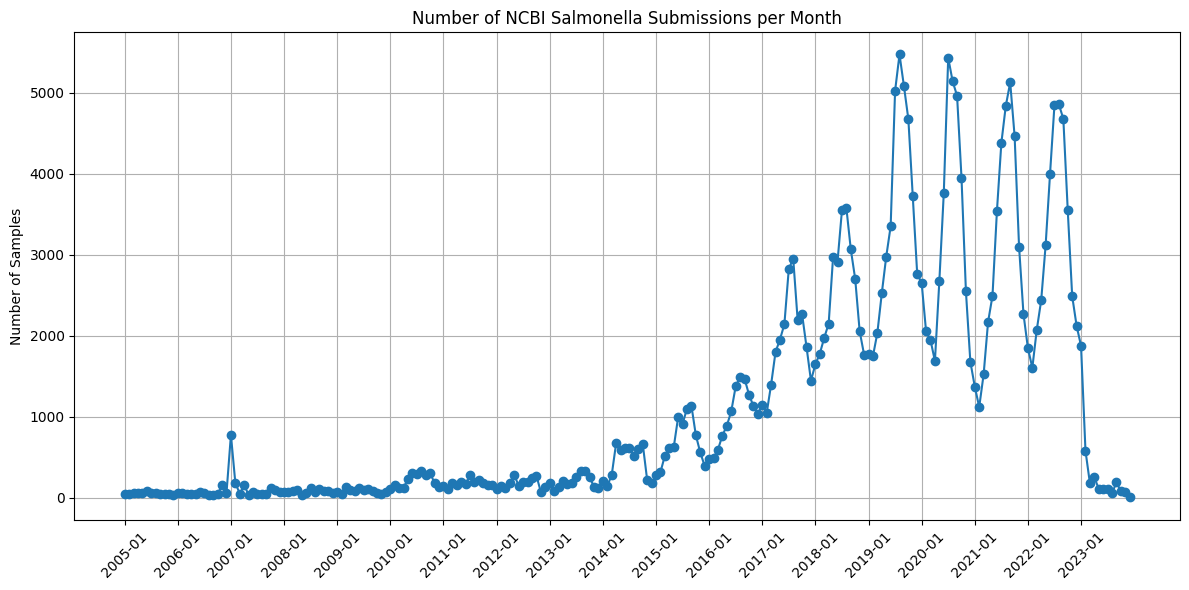

In [24]:
#make a line plot of the value_counts of year_and_month
year_month_counts = df['year_and_month'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
year_month_counts.plot(kind='line', marker='o')
plt.title('Number of NCBI Salmonella Submissions per Month')
plt.ylabel('Number of Samples')
#erase the x-axis label
plt.xlabel('')
plt.xticks(ticks=range(0, len(year_month_counts), 12), labels=year_month_counts.index[::12], rotation=45)
plt.grid()
plt.tight_layout()
plt.savefig('seasonal_ncbi_590.png')
plt.show()



In [25]:
#Similar to the NORS data, we see seasonal peaks during the summer months, and lows during winter months.